# Tutorial 7: Human ovarian cancer to identify CAF spatial subtypes

In [1]:
import remap
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Load ST reference and scRNA-seq data

##### In this example, we used human ovarian cancer Xenium data and aimed to recover the tissue spatial architecture and identify different spatial subtypes of cancer-associated fibroblasts (CAFs) characterized by distinct neighborhood compositions. The training and testing data are generated from the same patient.

In [2]:
Rdata = ad.read_h5ad("data/ovary/st_data.h5ad")
Qdata = ad.read_h5ad("data/ovary/sc_data.h5ad")
print(Rdata)
print(Qdata)

data_name = "ovary"
path_name =  f"remap_output/{data_name}"

AnnData object with n_obs × n_vars = 389895 × 5001
    obs: 'x_cord', 'y_cord', 'Cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'covet', 'spatial'
AnnData object with n_obs × n_vars = 389896 × 5001
    obs: 'x_cord', 'y_cord', 'Cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'covet'


## Initialize neighboring gene-gene covariance estimation.

##### After training, initialized neighboring gene-gene covariance for ST and scRNA-seq will be saved to `path_name` in `npy` format, named as `st_covariance.npy` and `sc_covariance.npy`.

In [3]:
Rdata, Qdata = remap.covet_init(st_data = Rdata, sc_data = Qdata, num_covet_genes=100, k_nearest=100,
                                 save_path = path_name, log_input = 1.0, lib_size = False, sample_gene = 500)

Loading precomputed neighboring gene-gene covariance


## Fit location prediction model.

##### The predicted locations will be saved to `path_name` in `npy` format, named as `remap_loc.npy`.
##### Since the training and testing data are from the same patient, Harmony is not needed.

In [4]:
pred_test = remap.Fit_cord_single(Rdata = Rdata, location_data = Rdata.obs[['x_cord', 'y_cord']], Qdata = Qdata, 
                    path_name = path_name, n_iter = 3, harmony = False)

Model is on GPU
No batch corrected expression found, use raw expression adata.
No batch corrected expression found, use raw expression adata.


Training, location_iter0: 100%|████████████████████████████████████| 500/500 [17:37<00:00,  2.12s/it, loss=0.7277]


Early stopping criteria reached.


Training, covariance_iter0: 100%|█████████████████████████████████| 500/500 [26:20<00:00,  3.16s/it, loss=66.9982]


Early stopping criteria reached.


...

Early stopping criteria reached.


Training, covariance_iter1: 100%|█████████████████████████████████| 500/500 [24:09<00:00,  2.90s/it, loss=15.0853]


Early stopping criteria reached.


Training, location_iter2: 100%|████████████████████████████████████| 500/500 [18:20<00:00,  2.20s/it, loss=0.5274]


Early stopping criteria reached.


##### Plot the predicted locations by REMAP.

In [5]:
pred_test = np.load(f"{path_name}/remap_loc.npy")
Qdata.obsm['spatial'] = np.array(Qdata.obs[['x_cord', 'y_cord']])
Qdata.obsm['remap'] = pred_test

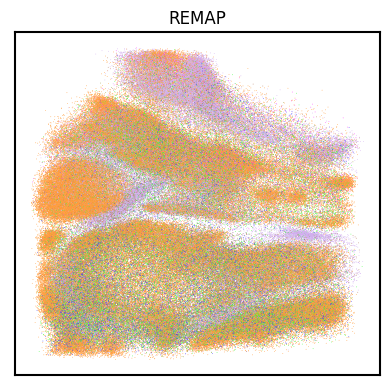

In [6]:
Qdata = Qdata[~pd.isna(Qdata.obs['Cluster']), :].copy()  ## remove the cells with NA cluster label

colors = {"Fibro": "#C798EE", "Macro": "#00FF00", "Tcell": "#0000FF", "Bcell": "#FF0000", "Epi": "#FFFF00", "Tumor": "#FF8000", "NK": "#FF00FF", "Musc": "#800080",
              "Endo": "#A0522D", "Neutro": "#008000", "Neuro": "#008000", "Mast": "#00FFFF", "DC": "#008080", "Peri": "#FFC0CB", "SMC": "#800000", "Plasma": "#808000"}

remap.scatter_plot(Qdata, colors, spatial_key = "remap", cluster_key = "Cluster", s = 0.25, save_path=path_name, filename="loc_remap", title = "REMAP")

## NMF-based neighborhood enrichment analysis

##### Here we apply NMF to the 3-hop neighborhood cell type composition matrix to obtain the neighborhood enrichment patterns. Before doing that, we need to transform the location coordinates to microns. 
##### In the `nmf_main` function, we define three radii (in micron) by `neighbor_radius` (the three numbers always increasing). `ct_key` indicates the column name of cell type in `Qdata.obs`. `ct_interest` indicates the cell type of interest for the NMF analysis. In this example, we focus on cancer-associated fibroblasts (CAFs). If `ct_interest = None`, NMF will be applied to all cells. `num_factor` specifies the number of factors in NMF.

/home/shunzhou/miniconda3/envs/py39/lib/python3.9/site-packages/sklearn/decomposition/_nmf.py:2341: ConvergenceWarning: Maximum number of iterations 10000 reached. Increase it to improve convergence.
  warnings.warn(


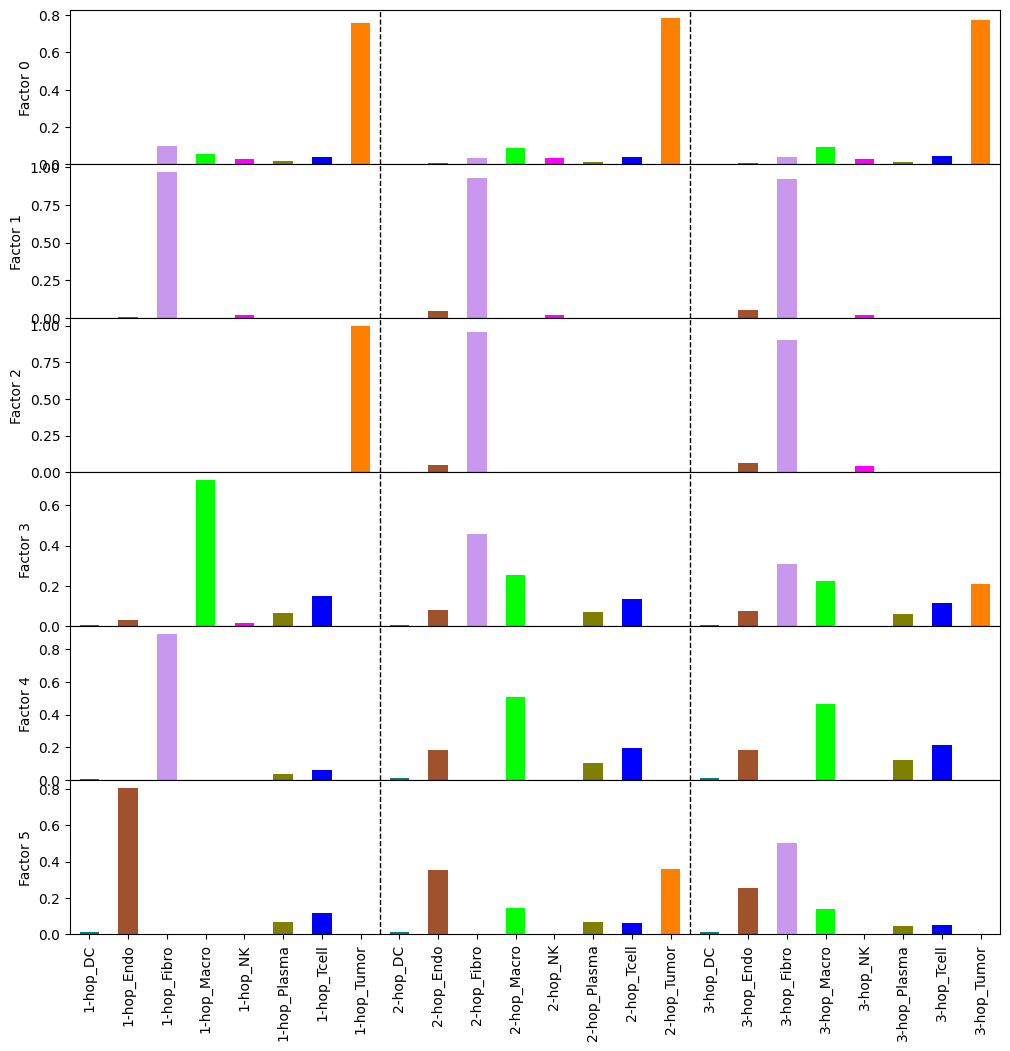

In [7]:
colors = {"Fibro": "#C798EE", "Macro": "#00FF00", "Tcell": "#0000FF", "Bcell": "#FF0000", "Epi": "#FF8000", "Tumor": "#FF8000", "NK": "#FF00FF", "Musc": "#800080",
                "Endo": "#A0522D", "Neutro": "#008000", "Neuro": "#008000", "Mast": "#00FFFF", "DC": "#008080", "Peri": "#FFC0CB", "SMC": "#800000", "Plasma": "#808000"}

remap.nmf_main(Qdata.obs, spatial = Qdata.obsm['remap'], path = path_name, colors = colors, ct_key = 'Cluster', ct_interest = 'Fibro', 
         neighbor_radius = [40, 80, 120], num_factor = 6, random_state=123)